## Customer Segmentation Using Unsupervised Learning
### Objective

The goal of this project is to segment mall customers into different groups based on their spending behaviour and annual income. Customer segmentation helps businesses understand different customer types and create targeted marketing strategies for each group.

### Step 1: Import Required Libraries

In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Import machine learning algorithms

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

### Step 2: Load the Dataset

In [26]:
# Load the Mall Customers dataset
df = pd.read_csv("Mall_Customers.csv")

In [5]:
# First 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Step 3: Explore the Dataset

In [7]:
# Check dataset dimensions
df.shape

(200, 5)


In [8]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [9]:
# Generate descriptive statistics

df.describe()

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


### Step 4: Check for Missing Values

In [10]:
# Check null values in each column
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Step 5: Gender Distribution

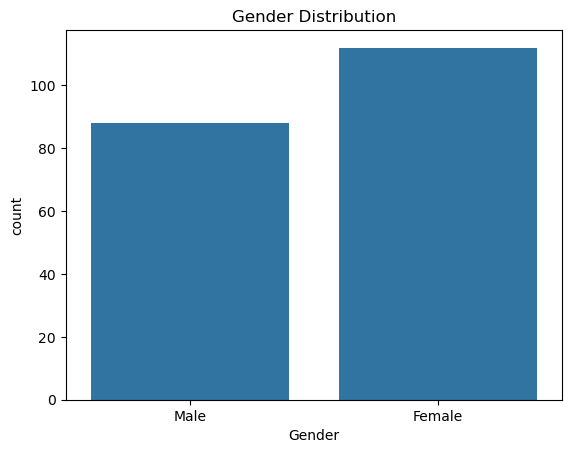

In [11]:
# Visualize gender distribution

sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

### Step 6: Age Distribution

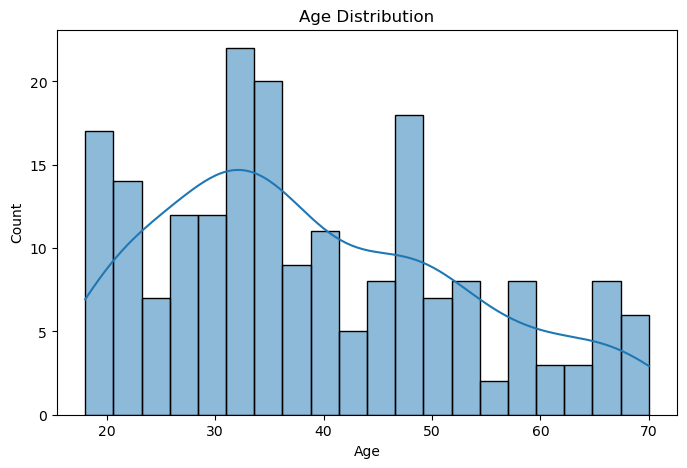

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],bins=20,kde=True)

plt.title("Age Distribution")
plt.show()

### Step 7: Annual Income Distribution

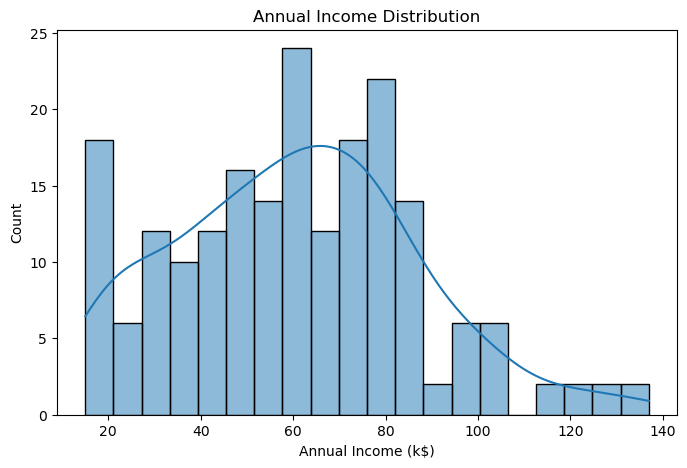

In [39]:
#plot annual income distribution 
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.show()

### Step 8: Spending Score Distribution

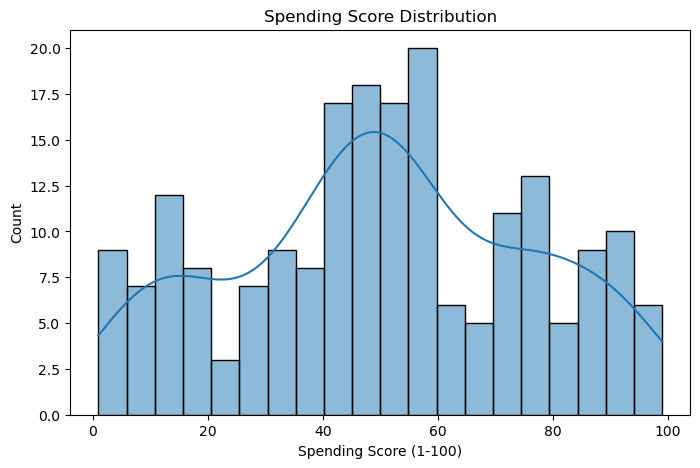

In [38]:
# Plot spending score distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20,kde=True)

plt.title("Spending Score Distribution")
plt.show()

### Step 9: Correlation Analysis

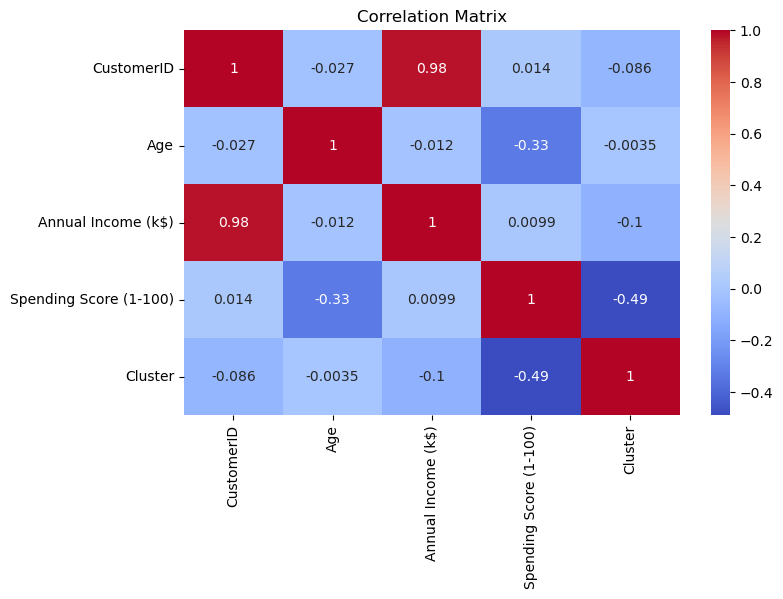

In [40]:
# Select numerical columns

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(),
           annot=True,
           cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

### Step 10: Select Features for Clustering

In [17]:
# Select features for customer segmentation
X = df[['Annual Income (k$)',
       'Spending Score (1-100)']]

### Step 11: Feature Scaling

In [19]:
# Standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Step 12: Determine Optimal Clusters Using Elbow Method

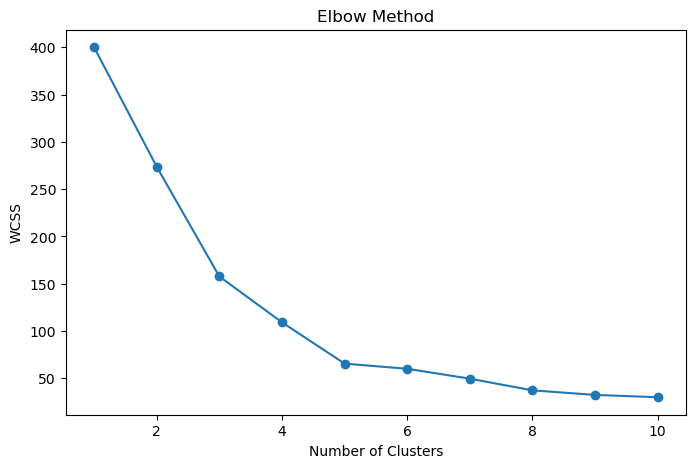

In [29]:
# Calculate WCSS for different cluster values
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

### Step 13: Apply K-Means Clustering

In [41]:
# Create KMeans model
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


### Step 14: Visualize Customer Segments

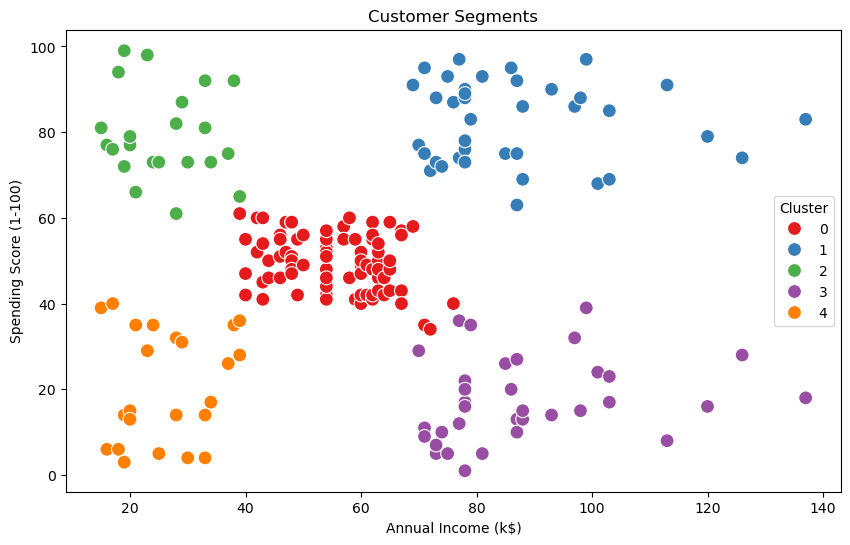

In [32]:
# Scatter plot of customer clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title("Customer Segments")

plt.show()

### Step 15: PCA for Dimensionality Reduction

In [34]:
#Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = clusters

### Step 16: PCA Visualization

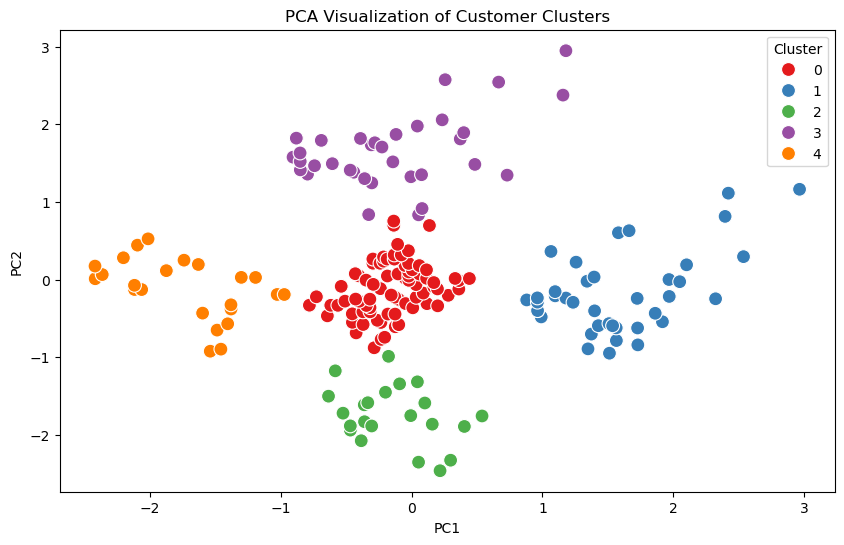

In [35]:
# Plot PCA clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    data=pca_df,
    s=100
)

plt.title("PCA Visualization of Customer Clusters")

plt.show()

### Step 17: Cluster Analysis

In [37]:
# Analyze average values per cluster

cluster_summary = df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)',
    'Age'
]].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


## Final Conclusion

This project successfully applied K-Means Clustering to segment mall customers based on their annual income and spending behavior. The Elbow Method identified five optimal clusters, while PCA helped visualize customer groups effectively. The analysis revealed distinct customer segments, allowing businesses to develop targeted marketing strategies and improve customer engagement.